# 데이터 불러오기

In [24]:
# 데이터 불러오기
import pandas as pd

subway21 = pd.read_csv("./train_subway21.csv")
subway22 = pd.read_csv('./train_subway22.csv')
subway23 = pd.read_csv('./train_subway23.csv')

In [28]:
subway21['train_subway21.direction'].unique()

array(['상선', '하선', '내선', '외선'], dtype=object)

In [11]:
# 외부 데이터 불러오기
import pandas as pd

trans21 = pd.read_csv("./transfer_2020.09.14.csv")
trans22 = pd.read_csv("./transfer_2022.12.22.csv")
trans23 = pd.read_csv("./transfer_2023.09.26.csv")
business_district = pd.read_csv("./business_district.csv")

In [12]:
# 한글 깨짐 방지
import matplotlib.font_manager as fm
for font in fm.fontManager.ttflist:
    if 'Gothic' in font.name or 'Batang' in font.name:
        print(font.name)
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 폰트
plt.rcParams['axes.unicode_minus'] = False     # 음수 부호 깨짐 방지

HCR Batang ExtB
Century Gothic
Franklin Gothic Book
Copperplate Gothic Light
Franklin Gothic Heavy
Franklin Gothic Demi
Yu Gothic
Malgun Gothic
HCR Batang ExtB
Hancom Gothic
HCR Batang Ext
Century Gothic
Yu Gothic
HYGothic-Extra
Franklin Gothic Heavy
Franklin Gothic Medium
Century Gothic
Yu Gothic
Showcard Gothic
Century Gothic
Yu Gothic
Franklin Gothic Medium
Franklin Gothic Book
Copperplate Gothic Bold
Franklin Gothic Demi Cond
HCR Batang
Franklin Gothic Demi
Batang
HCR Batang
MS Gothic
HYGothic-Medium
Franklin Gothic Medium Cond
Malgun Gothic
Malgun Gothic
Hancom Gothic


## (현서) 변수 열 추가

In [13]:
# 함수 설정) 전체 데이터 중 필요한(서울) 데이터 추출

def add_transfercol(df, exclude_col='RAIL_OPR_ISTT_CD', target_col='STIN_NM', result_col='TRANSFER', threshold=3):
    import re
    
    # 서울 외 지역 (ex. 부산, 광주) 행 리스트
    remove_list = ['EV', 'SW', 'BG', 'BS', 'DG', 'GJ', 'DJ']

    # exclude_col 값이 remove_list에 포함된 행 제거
    df_cleaned = df[~df[exclude_col].isin(remove_list)].copy()

    # 괄호 안 문자열 제거
    df_cleaned[target_col] = df_cleaned[target_col].str.replace(r"\([^)]*\)", "", regex=True).str.strip()

    # 괄호 포함 괄호 안 문자열 제거 (ex.'신촌(지하)' → '신촌') 및 특수 역 이름 매핑
    name_mapping = {
        '신촌': '신촌(지하)',
        '성수': '성수E',
        '신길온천': '능길',
        '하남검단산역': '하남검단산',
        '하남검산단역': '하남검단산',
        '응암': '응암S',
        '뚝섬유원지': '자양(뚝섬한강공원)'
    }
    df_cleaned[target_col] = df_cleaned[target_col].replace(name_mapping)

    # targel_col 개수 카운트
    value_counts = df_cleaned[target_col].value_counts()

    # TRANSFER 변수 추가
    df_cleaned[result_col] = df_cleaned[target_col].map(lambda x: 1 if value_counts[x] >= threshold else 0)

    # 중복 제거
    df_deduped = df_cleaned.drop_duplicates(subset=target_col)

    return df_deduped

In [14]:
trans21 = add_transfercol(trans21)
trans22 = add_transfercol(trans22)
trans23 = add_transfercol(trans23)

In [15]:
# station_name 기준으로 TRANSFER 열만 병합
subway21 = subway21.merge(
    trans21[['STIN_NM', 'TRANSFER']],
    how='left',
    left_on="train_subway21.station_name",
    right_on='STIN_NM'
)

subway22 = subway22.merge(
    trans22[['STIN_NM', 'TRANSFER']],
    how='left',
    left_on="train_subway22.station_name",
    right_on='STIN_NM'
)

subway23 = subway23.merge(
    trans23[['STIN_NM', 'TRANSFER']],
    how='left',
    left_on="train_subway23.station_name",
    right_on='STIN_NM'
)

In [16]:
# 함수 설정) station_name이 match_station_name과 같은 행은 stin_value -> STIN_NM, transfer_value -> TRANSFER 입력

def set_station_transfer21(df, match_station_name, stin_value=None, transfer_value=0):
    # match_station_name: station_name에서 찾을 문자열
    if stin_value is None:
        stin_value = match_station_name

    df.loc[df['train_subway21.station_name'] == match_station_name, 'STIN_NM'] = stin_value
    df.loc[df['train_subway21.station_name'] == match_station_name, 'TRANSFER'] = transfer_value
    return df
    
def set_station_transfer22(df, match_station_name, stin_value=None, transfer_value=0):
    # match_station_name: station_name에서 찾을 문자열
    if stin_value is None:
        stin_value = match_station_name

    df.loc[df['train_subway22.station_name'] == match_station_name, 'STIN_NM'] = stin_value
    df.loc[df['train_subway22.station_name'] == match_station_name, 'TRANSFER'] = transfer_value
    return df

def set_station_transfer23(df, match_station_name, stin_value=None, transfer_value=0):
    # match_station_name: station_name에서 찾을 문자열
    if stin_value is None:
        stin_value = match_station_name

    df.loc[df['train_subway23.station_name'] == match_station_name, 'STIN_NM'] = stin_value
    df.loc[df['train_subway23.station_name'] == match_station_name, 'TRANSFER'] = transfer_value
    return df

In [17]:
# TRANSFER이 결측치인 행 추출 후 지하철 이름 확인

# 2021
nan_rows_21 = subway21[subway21['TRANSFER'].isna()]
unique_stations_21 = nan_rows_21['train_subway21.station_name'].unique()

# 2022
nan_rows_22 = subway22[subway22['TRANSFER'].isna()]
unique_stations_22 = nan_rows_22['train_subway22.station_name'].unique()

# 2023
nan_rows_23 = subway23[subway23['TRANSFER'].isna()]
unique_stations_23 = nan_rows_23['train_subway23.station_name'].unique()

print(unique_stations_21)
print(unique_stations_22)
print(unique_stations_23)

['성수' '응암' '산곡' '남위례']
['성수' '응암']
['청산' '전곡' '연천' '성수' '응암']


In [18]:
# (데이터 확인 후) 누락 환승역 수기 설정

subway21 = set_station_transfer21(subway21,"산곡")
subway21 = set_station_transfer21(subway21,"남위례")
subway21 = set_station_transfer21(subway21,"성수")
subway21 = set_station_transfer21(subway21,"응암")

subway22 = set_station_transfer22(subway22, "성수")
subway22 = set_station_transfer22(subway22, "응암")

subway23 = set_station_transfer23(subway23, "청산")
subway23 = set_station_transfer23(subway23, "전곡")
subway23 = set_station_transfer23(subway23, "연천")
subway23 = set_station_transfer23(subway23, "성수")
subway23 = set_station_transfer23(subway23, "응암")

In [19]:
# train_subway21.hour 정수 전환
subway21['train_subway21.hour'] = subway21['train_subway21.tm'].astype(str).str[8:].astype(int)
subway22['train_subway22.hour'] = subway22['train_subway22.tm'].astype(str).str[8:].astype(int)
subway23['train_subway23.hour'] = subway23['train_subway23.tm'].astype(str).str[8:].astype(int)

# 출퇴근 시간대 여부 플래그 (7,8,9,17,18,19 → 1, 그 외 0)
peak_hours = [7, 8, 9, 17, 18, 19]
subway21['is_peak_hour'] = subway21['train_subway21.hour'].isin(peak_hours).astype(int)
subway22['is_peak_hour'] = subway22['train_subway22.hour'].isin(peak_hours).astype(int)
subway23['is_peak_hour'] = subway23['train_subway23.hour'].isin(peak_hours).astype(int)

In [21]:
# 정수형을 문자열로 변환
subway21['train_subway21.tm'] = subway21['train_subway21.tm'].astype(str)
subway22['train_subway22.tm'] = subway22['train_subway22.tm'].astype(str)
subway23['train_subway23.tm'] = subway23['train_subway23.tm'].astype(str)

# 앞 8자리 → 날짜, 뒤 2자리 → 시각
subway21['train_subway21.date'] = subway21['train_subway21.tm'].str[:8]
subway21['train_subway21.hour'] = subway21['train_subway21.tm'].str[8:]
subway22['train_subway22.date'] = subway22['train_subway22.tm'].str[:8]
subway22['train_subway22.hour'] = subway22['train_subway22.tm'].str[8:]
subway23['train_subway23.date'] = subway23['train_subway23.tm'].str[:8]
subway23['train_subway23.hour'] = subway23['train_subway23.tm'].str[8:]

# 시간은 정수형으로 변환 가능
subway21['train_subway21.hour'] = subway21['train_subway21.hour'].astype(int)
subway22['train_subway22.hour'] = subway22['train_subway22.hour'].astype(int)
subway23['train_subway23.hour'] = subway23['train_subway23.hour'].astype(int)

# 문자열을 datetime 형식으로 변환
subway21['train_subway21.date'] = pd.to_datetime(subway21['train_subway21.date'], format='%Y%m%d')
subway22['train_subway22.date'] = pd.to_datetime(subway22['train_subway22.date'], format='%Y%m%d')
subway23['train_subway23.date'] = pd.to_datetime(subway23['train_subway23.date'], format='%Y%m%d')

# 요일 열 추가
subway21['train_subway21.weekday'] = subway21['train_subway21.date'].dt.day_name()
subway22['train_subway22.weekday'] = subway22['train_subway22.date'].dt.day_name()
subway23['train_subway23.weekday'] = subway23['train_subway23.date'].dt.day_name()

# 주말 열 추가: 주말 → 1, 평일 → 0
subway21['train_subway21.weekend'] = subway21['train_subway21.weekday'].isin(['Saturday', 'Sunday']).astype(int)
subway22['train_subway22.weekend'] = subway22['train_subway22.weekday'].isin(['Saturday', 'Sunday']).astype(int)
subway23['train_subway23.weekend'] = subway23['train_subway23.weekday'].isin(['Saturday', 'Sunday']).astype(int)


# 한국 공휴일 라이브러리 설치 
# !pip install holidays

import holidays
import pandas as pd

# 전체 연도 추출
all_years = (
    pd.concat([
        subway21['train_subway21.date'],
        subway22['train_subway22.date'],
        subway23['train_subway23.date']
    ])
    .dt.year
    .unique()
)

# 공휴일 객체 생성
kr_holidays = holidays.KR(years=all_years)

# 공휴일 여부 컬럼 생성
subway21['is_holiday'] = subway21['train_subway21.date'].isin(kr_holidays).astype(int)
subway22['is_holiday'] = subway22['train_subway22.date'].isin(kr_holidays).astype(int)
subway23['is_holiday'] = subway23['train_subway23.date'].isin(kr_holidays).astype(int)

# 주말+공휴일 열 추가
subway21['is_offday'] = (subway21['train_subway21.weekend'] | subway21['is_holiday']).astype(int)
subway22['is_offday'] = (subway22['train_subway22.weekend'] | subway22['is_holiday']).astype(int)
subway23['is_offday'] = (subway23['train_subway23.weekend'] | subway23['is_holiday']).astype(int)

C:\Users\04032\AppData\Local\Temp\ipykernel_30360\3402963562.py:56: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  subway21['is_holiday'] = subway21['train_subway21.date'].isin(kr_holidays).astype(int)
C:\Users\04032\AppData\Local\Temp\ipykernel_30360\3402963562.py:57: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  subway22['is_holiday'] = subway22['train_subway22.date'].isin(kr_holidays).astype(int)
C:\Users\04032\AppData\Local\Temp\ipykernel_30360\3402963562.py:58: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. 

# 결측치 처리

#  함수 설정) 특정 날짜(결측치 처리 날짜) 이전까지 데이터를 평일/주말 기준으로 평균 혼잡도 계산 (이후 subway_df에 병합)
'''
변수 설명:
        target_stations: 분석 대상 역명
        cutoff_date: 결측치 처리 날짜 종료일
        station_col: 역명
        date_col: 날짜
        is_offday_col: 주말/공휴일 여부
        congestion_col: 혼잡도
'''

def assign_average_congestion_by_date_and_offday(
    subway_df,
    subway23,
    target_stations,
    cutoff_date=None,
    station_col='station_name',
    date_col='date',
    is_offday_col='is_offday',
    congestion_col='혼잡도'
):


    subset = subway23[subway23[station_col].isin(target_stations)].copy()

    # 결측치 날짜 설정
    if cutoff_date:
        subset = subset[pd.to_datetime(subset[date_col]) <= pd.to_datetime(cutoff_date)]

    # 평일/주말별 혼잡도 평균 계산
    avg = subset.groupby([station_col, is_offday_col])[congestion_col].mean().unstack(fill_value=0)

    # 열 지정
    avg.columns = ['평일평균혼잡도', '주말평균혼잡도'] if 0 in avg.columns else ['주말평균혼잡도']

    # 병합
    result = subway_df.merge(avg, how='left', left_on=station_col, right_index=True)

    return result

### 여기까비

target_stations = ['한대앞', '초지', '안산', '신길온천', '정왕', '오이도']

# subway21: 전체 기간 사용
subway21 = assign_average_congestion_by_date_and_offday(
    subway_df=subway21,
    subway23=subway23,
    target_stations=target_stations
)

# subway22: 2022년 6월 13일까지만 사용
subway22 = assign_average_congestion_by_date_and_offday(
    subway_df=subway22,
    subway23=subway23,
    target_stations=target_stations,
    cutoff_date='2022-06-13'
)

In [ ]:
# 주말 또는 공휴일일 경우 출퇴근 시간대가 아니라고 간주
subway21.loc[subway21['is_offday'] == 1, 'is_peak_hour'] = 0
subway22.loc[subway22['is_offday'] == 1, 'is_peak_hour'] = 0
subway23.loc[subway23['is_offday'] == 1, 'is_peak_hour'] = 0

In [27]:
import numpy as np

# 조건: 남위례 & 2021-12-18 이전
mask = (subway21['train_subway21.station_name'] == '남위례') & \
       (subway21['train_subway21.date'] < '2021-12-18')

subway21.loc[mask, 'train_subway21.congestion'] = np.nan

In [ ]:
## (지원) 상권지역 판단여부 전처리

In [28]:
def process_station_column(series):
    # 빈 값 제거 및 strip
    clean_lines = [str(line).strip() for line in series if str(line).strip() != ""]

    final_lines = []
    for line in clean_lines:
        # 하이픈(_) 있으면 하이픈 전까지만 남기기
        if "_" in line:
            line = line.split("_")[0]
        final_lines.append(line)

    print(f"{len(final_lines)}개의 줄이 최종 정리되었습니다.")

    unique_lines = list(set(final_lines))
    print(f"중복 제거 전: {len(final_lines)}줄")
    print(f"중복 제거 후: {len(unique_lines)}줄")

    station_only = [line for line in unique_lines if line.endswith("역")]
    print(f"총 {len(station_only)}개 역 이름이 있습니다.")

    return station_only

In [29]:
stations = process_station_column(business_district["station_name"])

393개의 줄이 최종 정리되었습니다.
중복 제거 전: 393줄
중복 제거 후: 276줄
총 125개 역 이름이 있습니다.


In [30]:
def attach_station_matches(train_df, station_only, station_col="station_name"):
    # 대표역명 사전 (필요에 따라 수정 가능)
    representative_stations = {
        '강남': '강남역',
        '동대문': '동대문역',
        '발산': '발산역',
        '사당': '사당역',
        '영등포': '영등포역'
        # 더 추가 가능
    }
    
    def pick_representative(station_name, matched_list):
        # 대표역명이 있으면 그것만 반환
        rep = representative_stations.get(station_name)
        if rep and rep in matched_list:
            return [rep]
        # 아니면 기존 리스트 그대로 반환
        return matched_list
    
    # matched_station 컬럼 추가
    train_df["matched_station"] = train_df[station_col].apply(
        lambda x: [station for station in station_only if x in station]
    )
    
    # 매칭 없으면 ["(매칭 없음)"]으로 대체
    train_df["matched_station"] = train_df["matched_station"].apply(
        lambda x: x if x else ["(매칭 없음)"]
    )
    
    # matched_station이 2개 이상이면 대표역명만 남김
    train_df["matched_station"] = train_df.apply(
        lambda row: pick_representative(row[station_col], row["matched_station"]) 
        if len(row["matched_station"]) >= 2 else row["matched_station"], axis=1
    )
    
    # 매칭 여부를 0/1로 표시
    train_df["main_street"] = train_df["matched_station"].apply(
        lambda x: 0 if x == ["(매칭 없음)"] else 1
    )
    
    return train_df

In [31]:
subway21 = attach_station_matches(subway21, stations,station_col="train_subway21.station_name")
subway22 = attach_station_matches(subway22, stations,station_col="train_subway22.station_name")
subway23 = attach_station_matches(subway23, stations,station_col="train_subway23.station_name")

In [32]:
# main street 0 -> 1 직접 변환

def update_main_street21(subway_df, new_station_names):
    # 조건: main_street == 0 이면서 station_name이 new_station_names에 포함된 경우
    condition = (subway_df['main_street'] == 0) & (subway_df['train_subway21.station_name'].isin(new_station_names))
    
    # main_street 값을 1로 변경
    subway_df.loc[condition, 'main_street'] = 1
    
    return subway_df

def update_main_street22(subway_df, new_station_names):
    # 조건: main_street == 0 이면서 station_name이 new_station_names에 포함된 경우
    condition = (subway_df['main_street'] == 0) & (subway_df['train_subway22.station_name'].isin(new_station_names))
    
    # main_street 값을 1로 변경
    subway_df.loc[condition, 'main_street'] = 1
    
    return subway_df

def update_main_street23(subway_df, new_station_names):
    # 조건: main_street == 0 이면서 station_name이 new_station_names에 포함된 경우
    condition = (subway_df['main_street'] == 0) & (subway_df['train_subway23.station_name'].isin(new_station_names))
    
    # main_street 값을 1로 변경
    subway_df.loc[condition, 'main_street'] = 1
    
    return subway_df

In [33]:
new_stations = ['회현', '신촌(지하)', '회기', '잠실새내', '을지로입구' , '혜화','목동', '문래','제기동', '디지털미디어시티', '녹사평', '혜화', '동대입구','어린이대공원','강변']  
subway21 = update_main_street21(subway21, new_stations)
subway22 = update_main_street22(subway22, new_stations)
subway23 = update_main_street23(subway23, new_stations)

# 확인
# changed_rows = subway21[(subway21['main_street'] == 1) & (subway21['train_subway21.station_name'].isin(new_stations))]
# print(changed_rows[['train_subway21.station_name', 'main_street']])

In [18]:
subway21

,Unnamed: 0,train_subway21.tm,train_subway21.line,train_subway21.station_number,train_subway21.station_name,train_subway21.direction,train_subway21.stn,train_subway21.ta,train_subway21.wd,train_subway21.ws,...,train_subway21.si,train_subway21.ta_chi,train_subway21.congestion,STIN_NM,TRANSFER,train_subway21.date,train_subway21.hour,train_subway21.weekday,matched_station,main_street
0,1,2021010100,1,150,서울역,상선,419,-9.6,291.1,3.3,...,-99.0,-12.6,0.0,서울역,1.0,2021-01-01,0,Friday,[(매칭 없음)],0
1,2,2021010101,1,150,서울역,상선,419,-9.7,284.6,2.0,...,-99.0,-9.8,0.0,서울역,1.0,2021-01-01,1,Friday,[(매칭 없음)],0
2,3,2021010105,1,150,서울역,상선,419,-9.3,124.7,2.4,...,-99.0,-10.3,1.0,서울역,1.0,2021-01-01,5,Friday,[(매칭 없음)],0
3,4,2021010106,1,150,서울역,상선,419,-9.3,126.2,1.7,...,-99.0,-10.1,2.0,서울역,1.0,2021-01-01,6,Friday,[(매칭 없음)],0
4,5,2021010107,1,150,서울역,상선,419,-9.1,145.7,1.3,...,-99.0,-9.7,3.0,서울역,1.0,2021-01-01,7,Friday,[(매칭 없음)],0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5452138,5452139,2021123119,8,2828,남위례,하선,572,-5.1,303.3,1.1,...,-99.0,-5.5,0.0,남위례,0.0,2021-12-31,19,Friday,[(매칭 없음)],0
5452139,5452140,2021123120,8,2828,남위례,하선,572,-5.6,307.8,0.8,...,-99.0,-5.9,0.0,남위례,0.0,2021-12-31,20,Friday,[(매칭 없음)],0
5452140,5452141,2021123121,8,2828,남위례,하선,572,-5.8,310.1,1.4,...,-99.0,-6.4,0.0,남위례,0.0,2021-12-31,21,Friday,[(매칭 없음)],0
5452141,5452142,2021123122,8,2828,남위례,하선,572,-6.3,300.3,1.2,...,-99.0,-6.8,0.0,남위례,0.0,2021-12-31,22,Friday,[(매칭 없음)],0


In [34]:
target_stations = ['한대앞', '초지', '안산', '신길온천', '정왕', '오이도']

# 역 이름이 target_stations에 있는 데이터만 필터링
filtered_df21 = subway21[subway21['train_subway21.station_name'].isin(target_stations)]
filtered_df22 = subway22[subway22['train_subway22.station_name'].isin(target_stations)]
filtered_df23 = subway23[subway23['train_subway23.station_name'].isin(target_stations)]

# 역별 평균 혼잡도 계산
avg_congestion21 = filtered_df21.groupby('train_subway21.station_name')['train_subway21.congestion'].mean().sort_values(ascending=False)
avg_congestion22 = filtered_df22.groupby('train_subway22.station_name')['train_subway22.congestion'].mean().sort_values(ascending=False)
avg_congestion23 = filtered_df23.groupby('train_subway23.station_name')['train_subway23.congestion'].mean().sort_values(ascending=False)

print(avg_congestion21)
print(avg_congestion22)
print(avg_congestion23)

train_subway21.station_name
안산     0.0
오이도    0.0
정왕     0.0
초지     0.0
한대앞    0.0
Name: train_subway21.congestion, dtype: float64
train_subway22.station_name
한대앞    7.423552
초지     3.870777
안산     2.655678
정왕     1.896554
오이도    0.845679
Name: train_subway22.congestion, dtype: float64
train_subway23.station_name
한대앞    18.943485
초지     12.694270
안산      9.331894
정왕      6.718668
오이도     2.526295
Name: train_subway23.congestion, dtype: float64


In [35]:
def preprocess_subway(df, year):
    df = df.copy()

    # 열 이름 접두어 지정
    prefix = f"train_subway{year}."

    # 필수 변수 alias (분석 및 보고용 모두 포함)
    df['tm'] = df[f'{prefix}tm']
    df['line'] = df[f'{prefix}line']
    df['station_number'] = df[f'{prefix}station_number']
    df['station_name'] = df[f'{prefix}station_name']
    df['direction'] = df[f'{prefix}direction']

    df['ta'] = df[f'{prefix}ta']
    df['ta_chi'] = df[f'{prefix}ta_chi']
    df['hm'] = df[f'{prefix}hm']
    df['ws'] = df[f'{prefix}ws']
    df['wd'] = df[f'{prefix}wd']
    df['si'] = df[f'{prefix}si']
    df['rainfall'] = df[f'{prefix}rn_day']
    df['rainfall_hourly'] = df[f'{prefix}rn_hr1']
    df['congestion'] = df[f'{prefix}congestion']
    df['hour'] = df[f'{prefix}hour']

    # 추가적으로 유용한 변수
    df['TRANSFER'] = df['TRANSFER']
    df['main_street'] = df['main_street']
    df['is_offday'] = df['is_offday']
    df['is_peak_hour'] = df['is_peak_hour']
    df['year'] = 2000 + year  # 예: 21 → 2021

    # 삭제 대상 열 (train_subway 접두어 있는 열 전체)
    drop_cols = [col for col in df.columns if col.startswith(prefix)]
    df.drop(columns=drop_cols, inplace=True, errors='ignore')

    return df

df21 = preprocess_subway(subway21, 21)
df22 = preprocess_subway(subway22, 22)
df23 = preprocess_subway(subway23, 23)

df_all = pd.concat([df21, df22, df23], ignore_index=True)

In [36]:
df21 = preprocess_subway(subway21, 21)
df22 = preprocess_subway(subway22, 22)
df23 = preprocess_subway(subway23, 23)

df_all = pd.concat([df21, df22, df23], ignore_index=True)

KeyError: 'is_offday'

# 주말 평일 

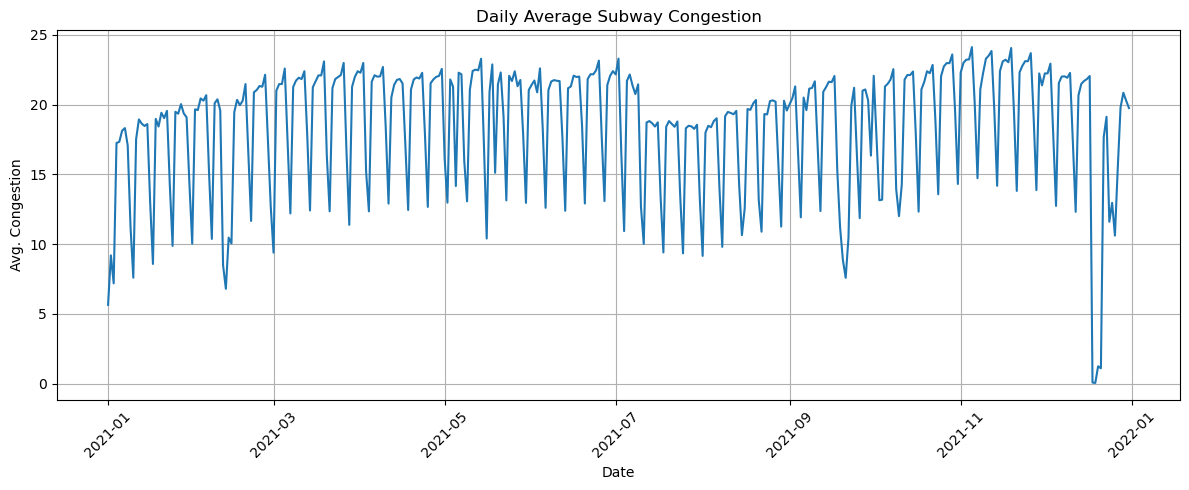

In [21]:
# 일별 평균 혼잡도 구해서 시각화
import matplotlib.pyplot as plt

daily_avg = subway21.groupby('train_subway21.date')['train_subway21.congestion'].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(daily_avg['train_subway21.date'], daily_avg['train_subway21.congestion'])
plt.xlabel('Date')
plt.ylabel('Avg. Congestion')
plt.title('Daily Average Subway Congestion')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
zero_rows = subway21[subway21['train_subway21.congestion'] == 0]
print(f"혼잡도 값이 0인 행 개수: {len(zero_rows)}")

# 혼잡도 0인 날짜 리스트
print("혼잡도 값이 0인 날짜들:")
print(zero_rows['train_subway21.date'].unique())

혼잡도 값이 0인 행 개수: 749778
혼잡도 값이 0인 날짜들:
<DatetimeArray>
['2021-01-01 00:00:00', '2021-01-02 00:00:00', '2021-01-03 00:00:00',
 '2021-01-04 00:00:00', '2021-01-05 00:00:00', '2021-01-06 00:00:00',
 '2021-01-07 00:00:00', '2021-01-08 00:00:00', '2021-01-09 00:00:00',
 '2021-01-10 00:00:00',
 ...
 '2021-12-22 00:00:00', '2021-12-23 00:00:00', '2021-12-24 00:00:00',
 '2021-12-25 00:00:00', '2021-12-26 00:00:00', '2021-12-27 00:00:00',
 '2021-12-28 00:00:00', '2021-12-29 00:00:00', '2021-12-30 00:00:00',
 '2021-12-31 00:00:00']
Length: 365, dtype: datetime64[ns]


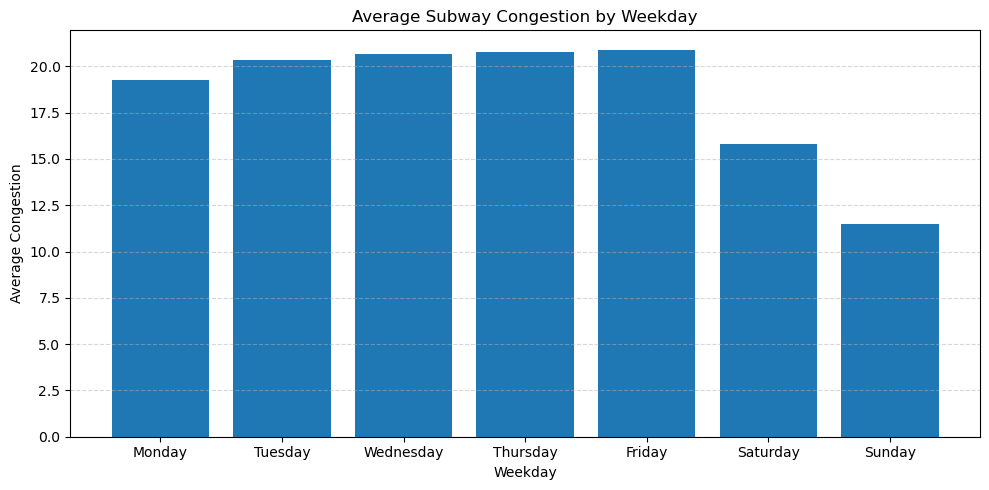

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 요일별 평균 혼잡도 계산
weekday_avg = subway21.groupby('train_subway21.weekday')['train_subway21.congestion'].mean().reset_index()

# 2. 요일 순서 정렬
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_avg['train_subway21.weekday'] = pd.Categorical(
    weekday_avg['train_subway21.weekday'],
    categories=weekday_order,
    ordered=True
)
weekday_avg = weekday_avg.sort_values('train_subway21.weekday')

# 3. 시각화
plt.figure(figsize=(10, 5))
plt.bar(weekday_avg['train_subway21.weekday'], weekday_avg['train_subway21.congestion'])
plt.xlabel('Weekday')
plt.ylabel('Average Congestion')
plt.title('Average Subway Congestion by Weekday')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 공휴일 합친 거

In [29]:
!pip install holidays

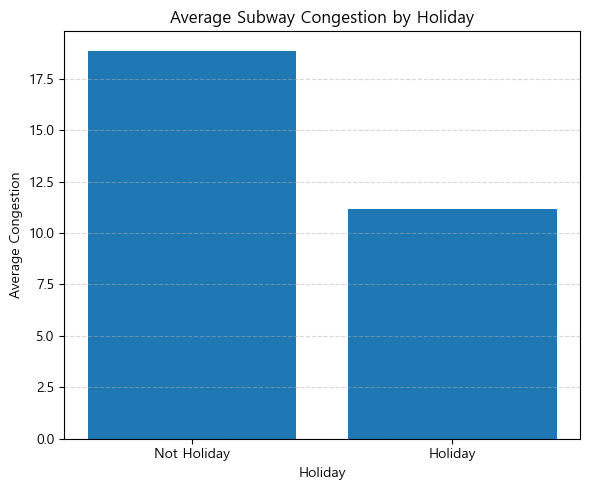

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 공휴일 여부별 평균 혼잡도 계산
holiday_avg = subway21.groupby('is_holiday')['train_subway21.congestion'].mean().reset_index()

# 2. 시각화
plt.figure(figsize=(6, 5))
plt.bar(holiday_avg['is_holiday'], holiday_avg['train_subway21.congestion'], tick_label=['Not Holiday', 'Holiday'])
plt.xlabel('Holiday')
plt.ylabel('Average Congestion')
plt.title('Average Subway Congestion by Holiday')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


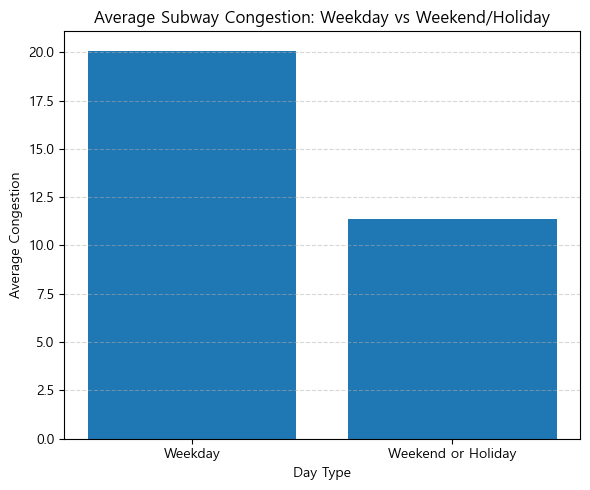

In [43]:
import pandas as pd
import matplotlib.pyplot as plt



# 2. 시각화
plt.figure(figsize=(6, 5))
plt.bar(offday_avg['is_weekend_or_holiday'], offday_avg['train_subway21.congestion'],
        tick_label=['Weekday', 'Weekend or Holiday'])

plt.xlabel('Day Type')
plt.ylabel('Average Congestion')
plt.title('Average Subway Congestion: Weekday vs Weekend/Holiday')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


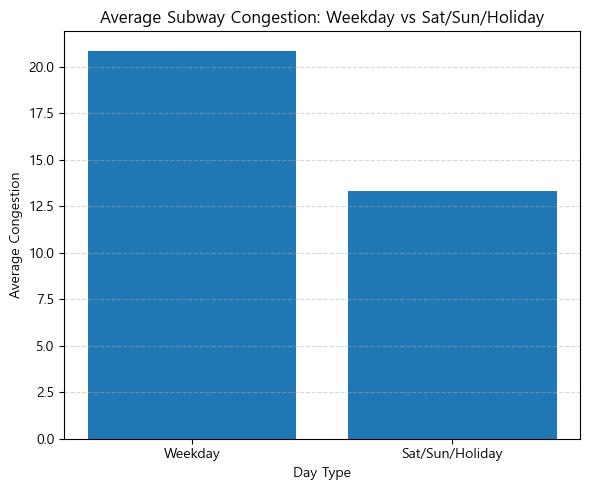

In [44]:
import pandas as pd
import matplotlib.pyplot as plt



# 2. 오프데이 여부별 평균 혼잡도 계산
offday_avg = subway21.groupby('is_offday')['train_subway21.congestion'].mean().reset_index()

# 3. 시각화
plt.figure(figsize=(6, 5))
plt.bar(offday_avg['is_offday'], offday_avg['train_subway21.congestion'],
        tick_label=['Weekday', 'Sat/Sun/Holiday'])

plt.xlabel('Day Type')
plt.ylabel('Average Congestion')
plt.title('Average Subway Congestion: Weekday vs Sat/Sun/Holiday')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [37]:
from scipy.signal import argrelextrema
import numpy as np

# 일별 평균 혼잡도 집계
daily_avg = subway21.groupby('train_subway21.date')['train_subway21.congestion'].mean().reset_index()

# 로컬 최소값 인덱스 찾기 (window=3 기준, 조정 가능)
min_idx = argrelextrema(daily_avg['train_subway21.congestion'].values, np.less, order=3)[0]

# 해당 날짜 추출
low_congestion_dates = daily_avg.iloc[min_idx]['train_subway21.date'].values

# datetime 배열이 numpy 형식일 경우
clean_dates = [str(d)[:10] for d in low_congestion_dates]

for date in clean_dates:
    print(date)

2021-01-10
2021-01-17
2021-01-24
2021-01-31
2021-02-07
2021-02-12
2021-02-21
2021-03-01
2021-03-07
2021-03-14
2021-03-21
2021-03-28
2021-04-04
2021-04-11
2021-04-18
2021-04-25
2021-05-02
2021-05-09
2021-05-16
2021-05-23
2021-05-30
2021-06-06
2021-06-13
2021-06-20
2021-06-27
2021-07-04
2021-07-11
2021-07-18
2021-07-25
2021-08-01
2021-08-08
2021-08-15
2021-08-22
2021-08-29
2021-09-05
2021-09-12
2021-09-21
2021-09-26
2021-10-03
2021-10-10
2021-10-17
2021-10-24
2021-10-31
2021-11-07
2021-11-14
2021-11-21
2021-11-28
2021-12-05
2021-12-12
2021-12-19
2021-12-26


# 상권 분석

## 호선별

In [42]:
line_congestion_mean = subway21.groupby('train_subway21.line')['train_subway21.congestion'].mean().reset_index()
print(line_congestion_mean)

# line_congestion_mean22 = subway22.groupby('train_subway22.line')['train_subway21.congestion'].mean().reset_index()
# line_congestion_mean23 = subway23.groupby('train_subway23.line')['train_subway21.congestion'].mean().reset_index()

   train_subway21.line  train_subway21.congestion
0                    1                  16.373848
1                    2                  25.349947
2                    3                  18.015541
3                    4                  16.023433
4                    5                  18.068321
5                    6                  13.241049
6                    7                  21.923449
7                    8                  19.385340


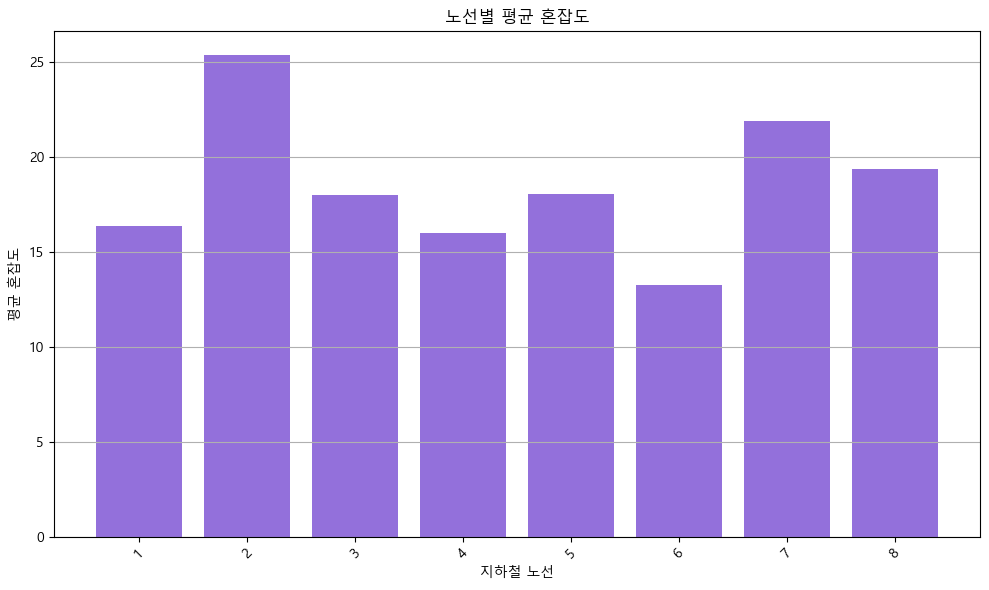

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(line_congestion_mean['train_subway21.line'], line_congestion_mean['train_subway21.congestion'], color='mediumpurple')

plt.title('노선별 평균 혼잡도')
plt.xlabel('지하철 노선')
plt.ylabel('평균 혼잡도')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [48]:
# 역별 평균 혼잡도 계산
avg_congestion_per_station = subway21.groupby('train_subway21.station_name')['train_subway21.congestion'].mean()

# 상위 10개 역 추출
top10_stations = avg_congestion_per_station.sort_values(ascending=False).head(10).reset_index()

print(top10_stations)

  train_subway21.station_name  train_subway21.congestion
0                          구일                  46.554338
1                         오류동                  41.211481
2                          서초                  37.105088
3                          방배                  37.098630
4                          송파                  35.897652
5                          강남                  35.280952
6                          석촌                  35.038617
7                         낙성대                  34.940900
8                          소사                  33.704566
9                          교대                  33.375408


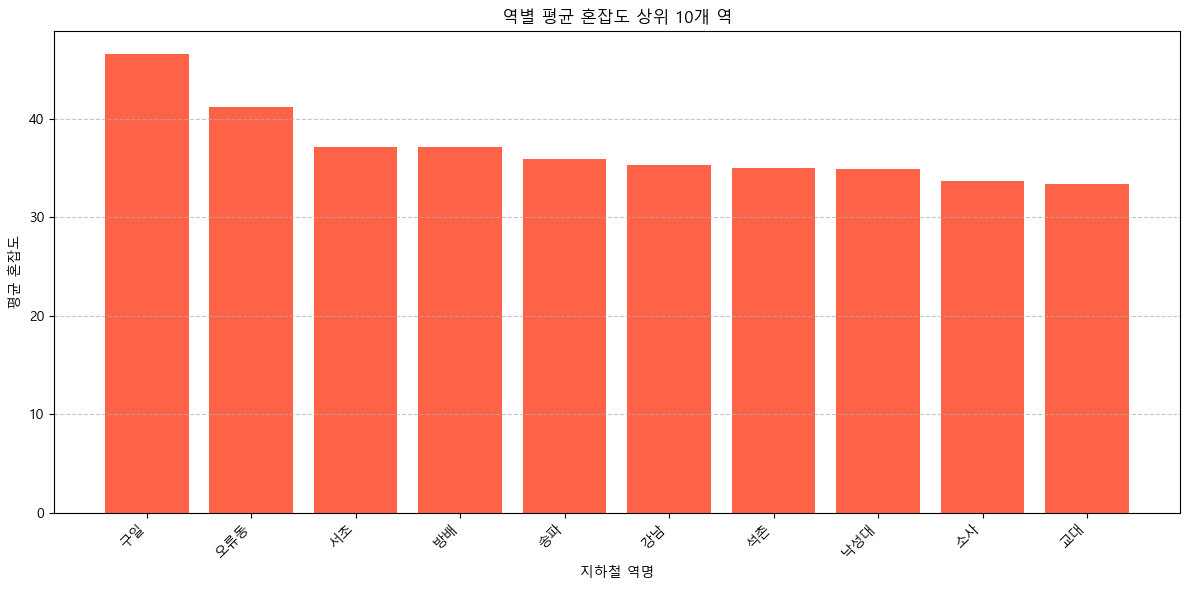

In [109]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(top10_stations['train_subway21.station_name'], top10_stations['train_subway21.congestion'], color='tomato')
plt.ylabel('평균 혼잡도')
plt.xlabel('지하철 역명')
plt.title('역별 평균 혼잡도 상위 10개 역')
plt.xticks(rotation=45, ha='right')  # 역명 45도 회전해서 보기 편하게
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 상권별 분석

In [50]:
distinct_station_names = subway21.loc[subway21['main_street'] == 0, 'train_subway21.station_name'].drop_duplicates()
distinct_station_names_list = distinct_station_names.tolist()
# distinct_station_names_list

In [51]:
main_subway21 = subway21[subway21['main_street'] == 1]
sub_subway21 = subway21[subway21['main_street'] == 0]
main_mean = main_subway21["train_subway21.congestion"].mean()
sub_mean = sub_subway21["train_subway21.congestion"].mean()

print(f"📌 주요 상권 혼잡도 평균: {main_mean:.2f}")
print(f"📌 비주요 상권 혼잡도 평균: {sub_mean:.2f}")


📌 주요 상권 혼잡도 평균: 20.69
📌 비주요 상권 혼잡도 평균: 16.56


In [52]:
trans_subway21 = subway21[subway21['TRANSFER'] == 1]
notrans_subway21 = subway21[subway21['TRANSFER'] == 0]

main_trans = trans_subway21["train_subway21.congestion"].mean()
sub_notrans = notrans_subway21["train_subway21.congestion"].mean()

In [53]:
congestion_grouped = subway21.groupby(['main_street', 'TRANSFER'])['train_subway21.congestion'].mean().reset_index()
print(congestion_grouped)

   main_street  TRANSFER  train_subway21.congestion
0            0       0.0                  16.560818
1            0       1.0                  16.735943
2            1       0.0                  20.537596
3            1       1.0                  21.851326


In [54]:
import pandas as pd

# pivot table 생성
pivot = subway21.pivot_table(
    values='train_subway21.congestion',
    index='main_street',
    columns='TRANSFER',
    aggfunc='mean'
)

print(pivot)


TRANSFER           0.0        1.0
main_street                      
0            16.560818  16.735943
1            20.537596  21.851326


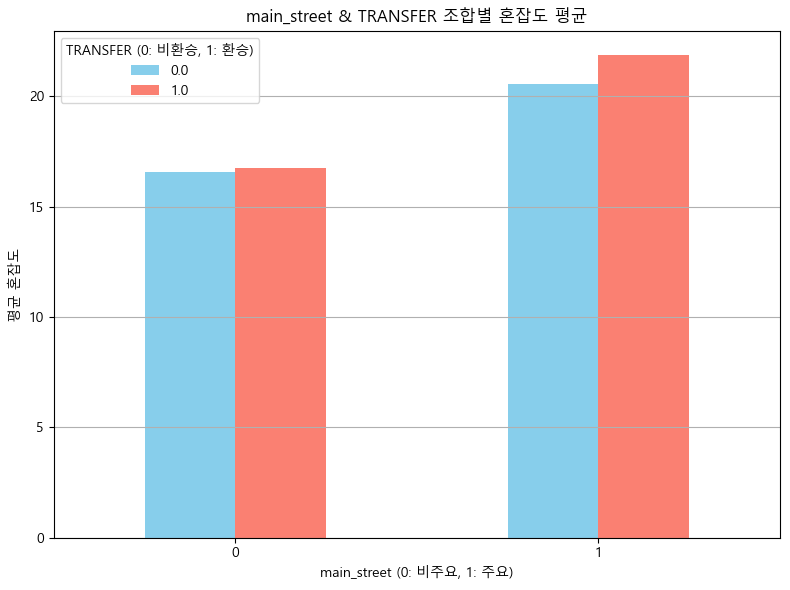

In [112]:
import matplotlib.pyplot as plt

# 막대그래프 그리기
pivot.plot(kind='bar', figsize=(8, 6), color=['skyblue', 'salmon'])

plt.title('main_street & TRANSFER 조합별 혼잡도 평균')
plt.xlabel('main_street (0: 비주요, 1: 주요)')
plt.ylabel('평균 혼잡도')
plt.legend(title='TRANSFER (0: 비환승, 1: 환승)')
plt.grid(axis='y')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

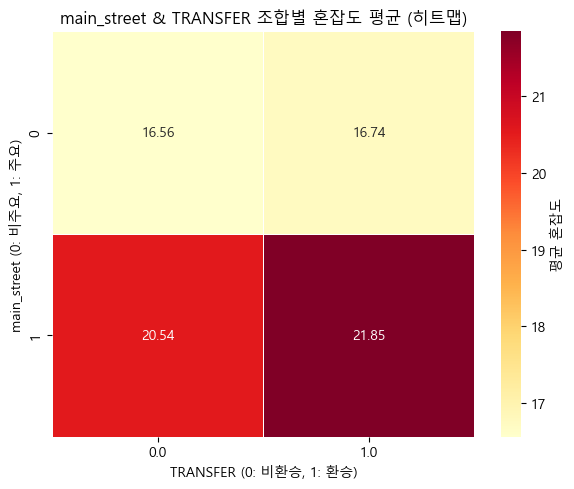

In [114]:
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5, cbar_kws={'label': '평균 혼잡도'})

plt.title('main_street & TRANSFER 조합별 혼잡도 평균 (히트맵)')
plt.xlabel('TRANSFER (0: 비환승, 1: 환승)')
plt.ylabel('main_street (0: 비주요, 1: 주요)')
plt.tight_layout()
plt.show()


C:\Users\0315j\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


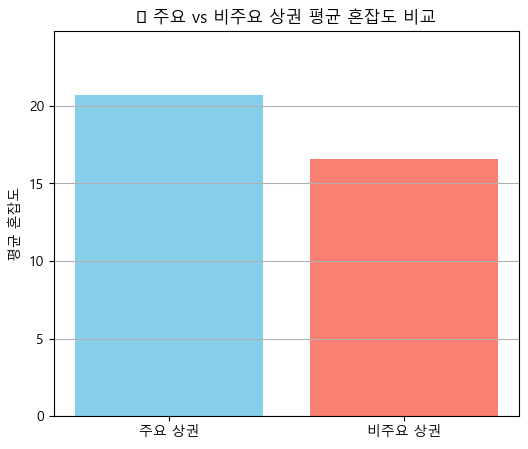

In [116]:
import matplotlib.pyplot as plt

# 데이터 준비
groups = ["주요 상권", "비주요 상권"]
means = [main_mean, sub_mean]

# 시각화
plt.figure(figsize=(6, 5))
plt.bar(groups, means, color=["skyblue", "salmon"])
plt.title("📊 주요 vs 비주요 상권 평균 혼잡도 비교")
plt.ylabel("평균 혼잡도")
plt.ylim(0, max(means)*1.2)  # y축 여유 있게
plt.grid(True, axis='y')
plt.show()

In [118]:
main_subway21 = subway21[subway21['main_street'] == 1]
sub_subway21 = subway21[subway21['main_street'] == 0]

main_X = main_subway21.drop(["train_subway21.congestion"], axis=1)
main_Y = main_subway21["train_subway21.congestion"]

sub_X = sub_subway21.drop(["train_subway21.congestion"], axis=1)
sub_Y = sub_subway21["train_subway21.congestion"]

# 함수 복붙

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
# intercept
model.intercept_
# coefficient
model.coef_
# import library
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# library for regression
from sklearn.linear_model import LinearRegression
from sklearn import datasets
# 그래프 배경화면을 격자 회색으로 설정
sns.set_theme(color_codes = True)

In [ ]:
X = mydata.iloc[:,:-1].values
Y = mydata.iloc[:, 1].values 
# model fitting
from sklearn.linear_model import LinearRegression
mymodel = LinearRegression()
mymodel.fit(X, Y)
LinearRegression()
print(f'intercept : {mymodel.intercept_}')
print(f'slope : {mymodel.coef_[0]}')
# Plotting the observation
plt.scatter(X, Y, color = "b")
# Plotting the regression line
plt.plot(X, mymodel.predict(X), color = "r") # R 의 line 함수와 동일
plt.title("Salary vs Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Salaries")
plt.show()
# Plotting the observed and fitted value
plt.scatter(Y, mymodel.predict(X), color = "b")
plt.plot(Y, Y, color = "r", label = "y=x") # y=x line
plt.xlabel("observed Y")
plt.ylabel("fitted Y")
plt.legend()
plt.show()
print(round(mymodel.score(X, Y), 3))

In [ ]:
# import dataset
mydata = datasets.load_diabetes()
mydata.keys()
dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename',
'target_filename', 'data_module'])

print('target : diabetes_score(당뇨병 수치)')
for i, feature_name in enumerate(mydata.feature_names):
 print(f'feature {i+1} : {feature_name}')
# model fitting
from sklearn.linear_model import LinearRegression
mymodel = LinearRegression()
mymodel.fit(X, Y)
LinearRegression()
# result
print(f'intercept : {mymodel.intercept_}')
for i, feature_name in enumerate(mydata.feature_names):
 print(f'{feature_name} coef : {mymodel.coef_[0,i]} ')
# Plotting the observed and fitted value
plt.scatter(Y, mymodel.predict(X), color = "b")
plt.plot(Y, Y, color = "r", label = "y=x")
plt.xlabel("observed Y")
plt.ylabel("fitted Y")
plt.legend()
plt.show()
print(round(mymodel.score(X,Y), 3))

In [ ]:
from sklearn.linear_model import LinearRegression
mymodel = LinearRegression()

main_subway21 = subway21[subway21['main_street'] == 1]
sub_subway21 = subway21[subway21['main_street'] == 0]

main_X = main_subway21.drop(["train_subway21.congestion"], axis = 1)
main_Y = main_subway21["train_subway21.congestion"]

sub_X = sub_subway21.drop(["train_subway21.congestion"], axis = 1)
sub_Y = sub_subway21["train_subway21.congestion"]

main_21model = mymodel.fit(main_X, main_Y)
LinearRegression()

sub_21model = mymodel.fit(sub_X, sub_Y)
LinearRegression()

In [ ]:
plt.scatter(main_Y, mymodel.predict(X), color = "b")
plt.plot(Y, Y, color = "r", label = "y=x")
plt.xlabel("observed Y")
plt.ylabel("fitted Y")
plt.legend()
plt.show()

In [ ]:
transfer_subway21 = subway21[subway21['TRANSFER'] == 1]
notrans_subway21 = subway21[subway21['TRANSFER'] == 0]

transfer_X = transfer_subway21.drop(["train_subway21.congestion"], axis = 1)
transfer_Y = transfer_subway21["train_subway21.congestion"]

notrans_X = notrans_subway21.drop(["train_subway21.congestion"], axis = 1)
notrans_Y = notrans_subway21["train_subway21.congestion"]

transfer_21model = mymodel.fit(transfer_X, transfer_Y)
LinearRegression()

notrans_21model = mymodel.fit(notrans_X, notrans_Y)
LinearRegression()

In [ ]:
from sklearn.linear_model import LinearRegression
mymodel = LinearRegression()

main_subway21 = subway21[subway21['main_street'] == 1]
sub_subway21 = subway21[subway21['main_street'] == 0]

main_X = main_subway21.drop(["train_subway21.congestion"], axis = 1)
main_Y = main_subway21["train_subway21.congestion"]

sub_X = sub_subway21.drop(["train_subway21.congestion"], axis = 1)
sub_Y = sub_subway21["train_subway21.congestion"]

main_21model = mymodel.fit(main_X, main_Y)
LinearRegression()

sub_21model = mymodel.fit(sub_X, sub_Y)
LinearRegression()

# 현서의 연습

In [99]:
import statsmodels.formula.api as smf

# 컬럼 정리
subway21['congestion'] = subway21['train_subway21.congestion']
subway21['rainfall'] = subway21['train_subway21.rn_day']

# 결측치 제거
data_basic = subway21.dropna(subset=['congestion', 'rainfall', 'is_offday'])

# 회귀 모형 (상호작용항 없이)
model_basic = smf.ols('congestion ~ rainfall + is_offday', data=data_basic).fit()

print("✅ 기본 회귀 결과 (상호작용항 없음)")
print(model_basic.summary())


✅ 기본 회귀 결과 (상호작용항 없음)
                            OLS Regression Results                            
Dep. Variable:             congestion   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                 1.191e+05
Date:                Sat, 21 Jun 2025   Prob (F-statistic):               0.00
Time:                        19:26:30   Log-Likelihood:            -2.3112e+07
No. Observations:             5452143   AIC:                         4.622e+07
Df Residuals:                 5452140   BIC:                         4.622e+07
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     20.8689      0.0

In [70]:
df = subway21.copy()

df['congestion'] = df['train_subway21.congestion']
df['rainfall'] = df['train_subway21.rn_day']
df['temp'] = df['train_subway21.ta']
df['humidity'] = df['train_subway21.hm']
df['windspeed'] = df['train_subway21.ws']
df['solar'] = df['train_subway21.si']


MemoryError: Unable to allocate 374. MiB for an array with shape (9, 5452143) and data type float64

In [124]:
import statsmodels.formula.api as smf

model_basic = smf.ols(
    formula="""
    congestion ~ rainfall + is_offday + is_peak_hour + 
    temp + humidity + windspeed + solar + 
    TRANSFER + main_street
    """,
    data=df.dropna()
).fit()

print(model_basic.summary())


                            OLS Regression Results                            
Dep. Variable:             congestion   R-squared:                       0.184
Model:                            OLS   Adj. R-squared:                  0.184
Method:                 Least Squares   F-statistic:                 1.366e+05
Date:                Sat, 21 Jun 2025   Prob (F-statistic):               0.00
Time:                        19:34:01   Log-Likelihood:            -2.2674e+07
No. Observations:             5452143   AIC:                         4.535e+07
Df Residuals:                 5452133   BIC:                         4.535e+07
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       18.9416      0.016   1200.936   

In [69]:
model_interact = smf.ols(
    formula="""
    congestion ~ rainfall * is_offday + rainfall * is_peak_hour + 
    temp + humidity + windspeed + solar + 
    TRANSFER + main_street
    """,
    data=df.dropna()
).fit()

print(model_interact.summary())


NameError: name 'smf' is not defined

In [65]:
subway.columns.tolist()

['Unnamed: 0',
 'train_subway21.tm',
 'train_subway21.line',
 'train_subway21.station_number',
 'train_subway21.station_name',
 'train_subway21.direction',
 'train_subway21.stn',
 'train_subway21.ta',
 'train_subway21.wd',
 'train_subway21.ws',
 'train_subway21.rn_day',
 'train_subway21.rn_hr1',
 'train_subway21.hm',
 'train_subway21.si',
 'train_subway21.ta_chi',
 'train_subway21.congestion',
 'STIN_NM',
 'TRANSFER',
 'year',
 'train_subway22.tm',
 'train_subway22.line',
 'train_subway22.station_number',
 'train_subway22.station_name',
 'train_subway22.direction',
 'train_subway22.stn',
 'train_subway22.ta',
 'train_subway22.wd',
 'train_subway22.ws',
 'train_subway22.rn_day',
 'train_subway22.rn_hr1',
 'train_subway22.hm',
 'train_subway22.si',
 'train_subway22.ta_chi',
 'train_subway22.congestion',
 'train_subway23.tm',
 'train_subway23.line',
 'train_subway23.station_number',
 'train_subway23.station_name',
 'train_subway23.direction',
 'train_subway23.stn',
 'train_subway23.ta',
 

# 모델링

In [22]:
import pandas as pd

# 병합
subway = pd.concat([subway21, subway22, subway23], ignore_index=True)

In [23]:
# 타겟 변수
y_train = df_train['congestion']

# 제외할 열(지원언니 받으면)
drop_cols = [
    'Unnamed: 0',                         # 인덱스
    'train_subway21.station_number',     # 번호
    'train_subway21.station_name',       # 문자열, 고유값 많음
    'train_subway21.tm',                 # 시각 코드
    'train_subway21.date',               # 날짜 객체 → 월 등 파생 가능
    'train_subway21.weekday',            # 요일 → is_offday로 대체
    'train_subway21.weekend',            # 중복
    'is_holiday',                        # 이미 is_offday, is_weekend_or_holiday 포함
    'is_weekend_or_holiday',             # is_offday로 충분히 표현됨
    'matched_station',                   # 참고용
    'STIN_NM'                            # 참조용
]


# 예측 변수
X_train = df_train.drop(columns=[col for col in drop_cols if col in df_train.columns])

# 범주형 변수 인코딩
X_train_encoded = pd.get_dummies(X_train, columns=['line', 'direction', 'year'], drop_first=True)

NameError: name 'df_train' is not defined

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train_encoded, y_train)

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
gbr_model.fit(X_train_encoded, y_train)

In [ ]:
from lightgbm import LGBMRegressor

lgb_model = LGBMRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
lgb_model.fit(X_train_encoded, y_train)


In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_encoded, y_train)